In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/processed/euskadi/listings_full_clean.csv")

## 2. Selección de variables de partida

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `host_location`. `amenities` es distinto: se trata aparte en la sección 9 (flags por palabra clave), no se descarta aquí.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms`), `license` (ya existe `has_license`), `host_name` (identificador) y `host_listings_count` (redundante con `calculated_host_listings_count`, recalculado sobre el propio dataset).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: variantes de `minimum_nights`/`maximum_nights`, de `availability`, y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

#### ¿Por qué se descarta `price_quote_*`?

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999874588)

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Texto libre sin estructura: la parte objetiva (tamaño, ubicación, equipamiento) ya está en columnas estructuradas, y sacar señal de texto de verdad requeriría NLP para un beneficio incierto. Se descartan de forma definitiva, igual que en las otras cinco ciudades.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(5670, 43)

Quedan 43 columnas de partida, el mismo número que en Sevilla (mismo esquema original de columnas). Incluye las dos columnas geográficas todavía sin codificar (`neighbourhood_cleansed`, `neighbourhood_group_cleansed`) y `property_type`.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_lice

## 3. Transformaciones numéricas

### 3.1 Logaritmos

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Se comprueba el efecto sobre `price`, la más asimétrica de todas.

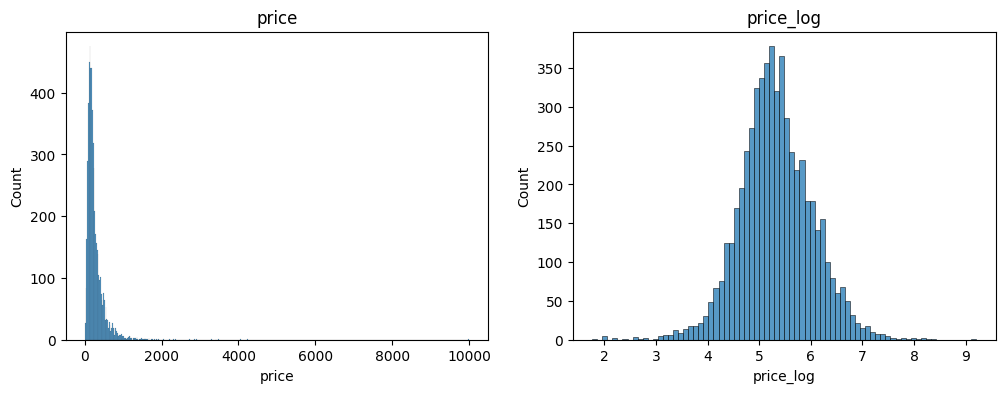

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")
plt.show()

La asimetría cae de 11.24 a prácticamente 0 (0.05): la distribución pasa de una cola muy larga a una forma casi normal, igual que en las otras cinco ciudades.

### 3.2 Ratios

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,5670.000000,5670.000000
mean,69.968019,189.532964
std,86.907395,238.282936
min,2.343750,0.053778
25%,39.877404,82.000000
50%,55.250000,137.000000
75%,81.296875,232.000000
max,4999.500000,9999.000000


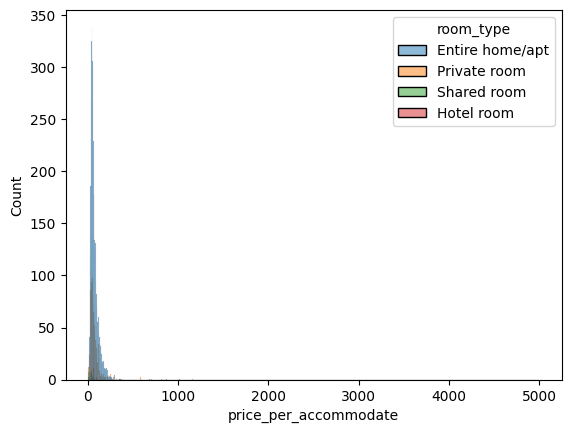

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")
plt.show()

## 4. Variables de tamaño: multicolinealidad

La correlación entre estas cuatro (0.61-0.81) es alta. Se calcula el VIF para valorar si hace falta combinar o descartar alguna antes de un modelo lineal.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    4.305979
bedrooms        3.566179
beds            3.408508
bathrooms       2.081737
Name: VIF, dtype: float64

Los cuatro VIF están entre 2.08 y 4.31 — más altos que Sevilla (1.8-3.8) y Valencia (1.3-2.7), pero todavía por debajo del umbral de 5. `bathrooms` vuelve a ser la que menos se solapa con las otras tres (VIF 2.08), y `accommodates` la que más (VIF 4.31, la más cercana al umbral vista hasta ahora entre las ciudades con jerarquía de dos niveles). Se mantienen las cuatro tal cual, sin combinarlas ni descartar ninguna.

Como en las otras ciudades, esto solo importaría de verdad para un modelo lineal. Si más adelante los coeficientes de estas variables salen inestables entre folds, este es el sitio al que volver.

## 5. Codificación de categóricas

Cuatro categóricas necesitan tratamiento: `room_type` y `neighbourhood_group_cleansed` (provincia, solo 3 categorías) son pocas y se codifican directamente; `neighbourhood_cleansed` (207 municipios) y `property_type` (61 tipos) tienen demasiadas para un one-hot directo.

### 5.1 `room_type`

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_group_cleansed` (provincia)

In [13]:
df = pd.get_dummies(df, columns=["neighbourhood_group_cleansed"], prefix="district")

Solo 3 columnas (`district_Vizcaya`, `district_Guipúzcoa`, `district_Álava`), muchas menos que en Sevilla (11) o Valencia — Euskadi tiene la jerarquía de provincia/municipio más desequilibrada de las ciudades con dos niveles: un primer nivel muy grueso (3) y un segundo nivel muy fino (207).

### 5.3 `neighbourhood_cleansed` (municipio)

**Aviso importante**: esta media se calcula aquí con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook — no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 10, en vez de descartarse aquí mismo: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split.

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False).head(10)

,neighbourhood_cleansed,neighbourhood_price_encoded
103,Sondika,556.629349
0,Donostia-San Sebastián,386.544043
998,Arratzu,348.005557
14,Gatika,344.536445
267,Aia,339.218087
261,Zeanuri,332.137409
791,Zierbena,328.244772
847,Atxondo,327.769261
5504,Nabarniz,322.414648
379,Hernani,319.294214


**Sondika encabeza la lista (556.6€) por delante incluso de Donostia-San Sebastián (386.5€)**, y es un artefacto conocido: de sus 19 anuncios, uno es justo el precio disuasorio de 9.999€ ya detectado en la sección 8.2 de la EDA ("Habitación doble con supletoria niño en Sondika"). Sin esa fila, la media de Sondika baja de 710.3€ a 194.3€ — con `smoothing=10` no es suficiente para neutralizar un solo valor tan extremo en un grupo de solo 19. Confirma, con un ejemplo muy concreto, por qué esta versión de la columna es solo provisional: el recalculo con datos de entrenamiento en `03_model_baseline.ipynb` no arregla este problema de fondo, pero al menos evita que se filtre al test.

### 5.4 `property_type`

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

20

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

20 categorías tras agrupar (19 + `Other`), la cifra más alta de las seis ciudades — coherente con que también partía del `property_type` más diverso (61 categorías en la EDA). Con esto, `room_type`, `neighbourhood_group_cleansed` y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` como la única categórica de alta cardinalidad pendiente de resolver correctamente en el split.

## 6. Variables derivadas del host

### 6.1 Antigüedad del host

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    5670.000000
mean        6.229145
std         3.717151
min         0.000000
25%         3.000000
50%         6.250000
75%         9.083333
max        15.083333
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 62.7%
más de 2 anuncios: 50.7%
más de 5 anuncios: 32.6%
más de 10 anuncios: 23.2%


Con `> 1` solo el 62.7% se marca como "profesional" (la mediana de `calculated_host_listings_count` es 3) — un mercado bastante menos concentrado en gestoras grandes que Sevilla (76.7% con mediana 6).

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,2116,209.665
pequeno,2236,171.725
mediano,1084,200.000
grande,234,355.500


No monótona (209.67€ → 171.73€ → 200.00€ → 355.50€): baja de `individual` a `pequeno` y solo remonta a partir de `mediano`, el mismo patrón en "U" que en Sevilla, aunque aquí el salto final a `grande` es mucho más pronunciado. Se codifica con one-hot: no tiene sentido asumir un orden numérico que ni siquiera aquí se cumple.

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.21873424084584864)

0.22 de correlación con `price`, claramente por encima del propio `calculated_host_listings_count` (0.16) — a diferencia de Sevilla (0.07 vs. 0.03, apenas se diferenciaban), aquí la composición del portfolio del host (cuánto de él son viviendas enteras) aporta más señal que su tamaño en bruto.

## 7. Variables derivadas de reviews

### 7.1 `has_reviews`

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     5134
False     536
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,5134.000000,5134.000000
mean,1584.189326,146.107519
std,1136.329331,317.744528
min,2.000000,0.000000
25%,692.000000,13.000000
50%,1333.000000,30.000000
75%,2504.500000,105.750000
max,5507.000000,3646.000000


In [25]:
df["listing_age_days"].corr(df["price"]), df["days_since_last_review"].corr(df["price"])

(np.float64(0.08906047553506724), np.float64(0.022444716641611233))

Ambas quedan `NaN` para los anuncios sin reviews (536, exactamente el mismo recuento que `has_reviews == False`), coherente por construcción. `listing_age_days` (0.09) y `days_since_last_review` (0.02) apenas correlacionan con `price`, igual que en el resto de ciudades.

### 7.3 Los 6 subscores de review

In [26]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA salía débil en ambos casos (Pearson 0.074, Spearman 0.172), inventar un valor no aportaría nada de forma fiable.

## 8. Variables geográficas

### 8.1 Distancia al centro: un problema propio de Euskadi

A diferencia de las otras cinco ciudades, aquí no hay un único centro evidente: Bilbao, Donostia-San Sebastián y Vitoria-Gasteiz son tres capitales de provincia con peso turístico muy distinto (sección 9 de la EDA). En vez de forzar un único punto de referencia, `distance_to_center_km` se calcula como la **distancia a la capital de provincia más cercana** de las tres.

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


capitals = {
    "Bilbao": (43.2630, -2.9350),                    # Plaza Moyúa
    "Donostia-San Sebastián": (43.3183, -1.9812),     # Ayuntamiento / Playa de la Concha
    "Vitoria-Gasteiz": (42.8467, -2.6716),            # Plaza Virgen Blanca
}

dists_to_capitals = pd.DataFrame({
    name: haversine(df["latitude"], df["longitude"], lat, lon)
    for name, (lat, lon) in capitals.items()
})
df["distance_to_center_km"] = dists_to_capitals.min(axis=1)
df["nearest_capital"] = dists_to_capitals.idxmin(axis=1)

df["distance_to_center_km"].describe()

count    5670.000000
mean        9.800796
std        11.367342
min         0.001376
25%         0.909202
50%         2.314366
75%        16.536700
max        42.433474
Name: distance_to_center_km, dtype: float64

In [28]:
df["nearest_capital"].value_counts()

nearest_capital
Bilbao                    3022
Donostia-San Sebastián    2195
Vitoria-Gasteiz            453
Name: count, dtype: int64

3022 anuncios están más cerca de Bilbao, 2195 de Donostia y solo 453 de Vitoria-Gasteiz — reparto coherente con el peso de cada provincia visto en la EDA.

In [29]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(-0.09331505773994028), np.float64(-0.2663870901784374))

Correlación global débil (-0.09 con `price`, -0.27 con `neighbourhood_price_encoded`), pero esconde tres patrones opuestos según la capital más cercana:

In [30]:
for cap in capitals:
    sub = df[df["nearest_capital"] == cap]
    corr = sub["distance_to_center_km"].corr(sub["price"])
    print(f"{cap}: n={len(sub)}, corr={corr:.3f}")

Bilbao: n=3022, corr=0.024
Donostia-San Sebastián: n=2195, corr=-0.239
Vitoria-Gasteiz: n=453, corr=0.253


En la órbita de **Donostia** el patrón es el clásico centro-periferia (-0.24, más cerca = más caro). En la órbita de **Bilbao** es prácticamente plano (0.02): ciudad de negocios, no de playa. Y en la órbita de **Vitoria-Gasteiz** el signo se invierte (+0.25): alejarse de la capital (más barata, sección 9 de la EDA) hacia el campo alavés sube el precio, el mismo patrón de turismo rural ya visto con `Entire cottage` en la EDA. Tres mercados geográficos distintos dentro de la misma variable — se mantiene `nearest_capital` solo como columna auxiliar de diagnóstico, no como feature del modelo.

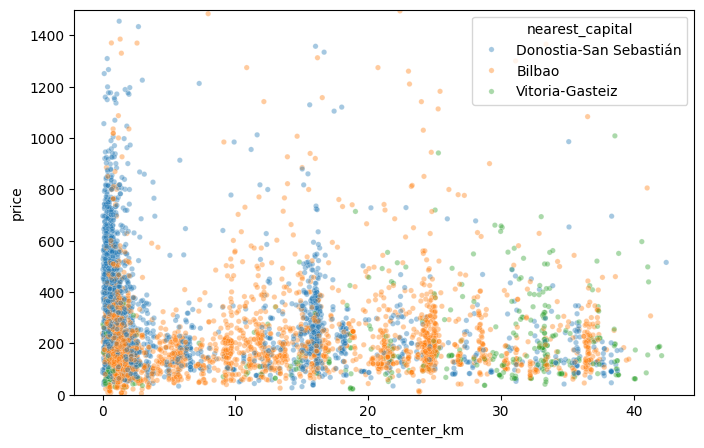

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="distance_to_center_km", y="price", hue="nearest_capital", alpha=0.4, s=15)
plt.ylim(0, 1500)
plt.show()

### 8.2 Densidad de anuncios cercanos

In [32]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    5670.000000
mean       19.181658
std        24.972671
min         0.000000
25%         2.000000
50%         8.000000
75%        29.000000
max       137.000000
Name: n_nearby_150m, dtype: float64

In [33]:
df["n_nearby_150m"].corr(df["price"])

np.float64(0.08476619831411436)

Mismo resultado que en la EDA (correlación 0.08, débil): más densidad se asocia a zonas turísticas caras (Casco Viejo de Bilbao, centro de Donostia), no a un efecto de saturación de precios. Se mantiene por consistencia con el resto de ciudades.

## 9. Amenities

### 9.1 Parsear y construir los flags

In [34]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)


def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False


df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition"]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["has_sea_view"] = amenities_parsed.apply(lambda l: has_any(l, ["sea view", "beach view", "ocean view"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "has_sea_view", "n_amenities"]].describe(include="all")

,has_ac,has_pool,has_dishwasher,has_sea_view,n_amenities
count,5670,5670,5670,5670,5670.000000
unique,2,2,2,2,NaN
top,False,False,False,False,NaN
freq,4719,5332,2853,5380,NaN
mean,NaN,NaN,NaN,NaN,32.048501
std,NaN,NaN,NaN,NaN,15.766541
min,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,33.000000
75%,NaN,NaN,NaN,NaN,44.000000


Prevalencias y correlaciones idénticas a las de la EDA (`has_dishwasher` 49.7%/corr 0.197, `has_ac` 16.8%/0.057, `has_pool` 6.0%/0.113, `has_sea_view` 5.1%/0.097, `n_amenities` media 32.0): `has_dishwasher` sigue siendo la candidata más fuerte, y `has_sea_view` — nueva, como en Mallorca — se mantiene por ser la única variable de las cuatro con una interpretación geográfica clara (litoral de Donostia a Bilbao).

### 9.2 Descartar `amenities`

In [35]:
df = df.drop(columns=["amenities"])
df.shape

(5670, 89)

## 10. Dataset final para modelado

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

In [36]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

In [37]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "nearest_capital",
]

df = df.drop(columns=final_drop)
df.shape

(5670, 79)

### 10.3 Comprobación de nulos

In [38]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      536
listing_age_days          536
days_since_last_review    536
dtype: int64

Las tres coinciden exactamente en las mismas 536 filas (`has_reviews == False`), tal y como se esperaba. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

In [39]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 74


79 columnas en total: 3 identificadores, 1 objetivo, 1 pendiente y **74 features** — muy cerca de Sevilla (74) pese a partir de una jerarquía geográfica muy distinta (3 dummies de `district_*` frente a 11, compensado por 20 dummies de `property_type` frente a 13).

### 10.5 Exportar

In [40]:
df.to_csv(f"{PROJECT_DIR}/data/processed/euskadi/listings_full_features.csv", index=False)